## Aprendizaje Automático III
### Práctica 03: Estimación de densidades

**Equipo de laboratorio:** 12  
**Nombre (miembro 1):** Iván Domínguez Hernández  
**Nombre (miembro 2):** Lucas Miranda López 

### Instrucciones Generales

* **Identificación:** Incluid el **nombre de todos los miembros del equipo de laboratorio al inicio de todos los archivos** entregados.
* **Ejecución:** Entregad este cuaderno de Python con **todas las celdas ejecutadas** de manera secuencial. Aseguraos de que el código se ejecuta sin errores (**Kernel -> Restart & Run All**). Los errores de ejecución pueden ser penalizados.
* **Modularización:** Las funciones deben definirse en un **archivo separado (.py)**, no en el notebook. Incluid en la entrega todos los archivos necesarios para la ejecución.
* **Informe:** El informe será evaluado por su **corrección, claridad, concisión y completitud**.
* **Presentación de resultados:** Utilizad **figuras y tablas** para presentar los resultados e ilustrar las conclusiones.
* **Fuentes y referencias:** se pueden usar materiales del curso y fuentes externas. Las **fuentes deben ser citadas** en formato APA ([Guía APA 7](https://pitt.libguides.com/citationhelp/apa7)). La falta de referencias o el uso de un formato incorrecto serán penalizados.
* **IA Generativa:** Se permite el uso de herramientas de IA (especificando cuales) para realizar consultas y mejorar la redacción del informe. **Está estrictamente prohibido utilizar IA para generar código o texto que se integre de manera literal**** en el cuaderno.

---

### Formato de Entrega

La entrega debe ser un único archivo `.zip` cuyo nombre sea:  
`AA3_2025_2026_P03_<equipo_lab>_<apellido1_1>_<apellido2_1>.zip`  
*(Ejemplo: `AA3_2025_2026_P03_13_munyoz_deLaRosa.zip`)*

**El archivo comprimido debe contener:**
1.  **Este notebook de Python** con las soluciones (código, figuras, tablas y explicaciones). Las derivaciones manuscritas pueden incluirse como imágenes.
2.  **Archivos `.py` y adicionales** necesarios para que la ejecución del cuaderno de Python.
3.  **Archivo PDF** generado desde el notebook (Exportar a HTML -> Imprimir como PDF).

In [49]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Ejercicio 1: Estimación de la densidad con Parzen


En este ejercicio analizaremos el uso de **estimadores de densidad basados en kernels (ventanas de Parzen)** y cómo su rendimiento depende de la **dimensión del espacio de datos**.

Supongamos que tenemos un conjunto de datos $x_1,\dots,x_N$ generado a partir de una distribución desconocida $p(x)$.

La estimación de densidad mediante ventanas de Parzen se define como:

$$
\hat p(x) =
\frac{1}{N h^D}
\sum_{n=1}^{N}
K\left(\frac{\|x-x_n\|_2}{h}\right)
$$

donde:

- $K(\cdot)$ es un **kernel** (por ejemplo, gaussiano),
- $h$ es el **ancho de banda**,
- $d$ es la **dimensión de los datos**.

Realice las siguientes tareas: 
1. Implemente el estimador de densidad (fichero `.utils/parzen_density.py`).
2. ¿Cómo seleccionaría $h$?
3. Estudie el error en función de el número de muestras y de la dimensión del espacio de entrada. 

Para ello realizarán dos experimentos: 

i. Fije el número de muestras y aumente la dimensión, ¿cómo evoluciona el error entre la función de densidad original y la estimada?

ii. Fije la dimensión y aumente el número de muestras. ¿Cómo evoluciona el error entre la función de densidad original y la estimada?


Como ayuda dispone de una función que genera datos sintéticos, en la siguiente celda tiene un ejemplo de cómo usarla. 
Para medir el error tiene las siguientes métricas posibles: MSE, KL divergence, JS divergence o total variation.

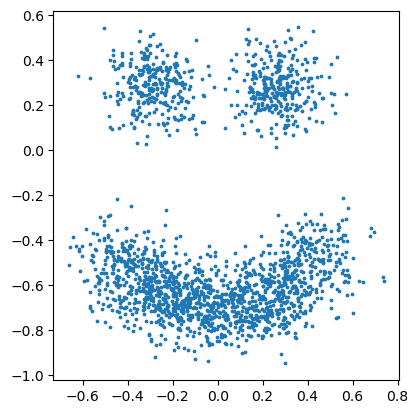

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV
from utils.generate_probability_density_data import generate_density, sample_from_density
from models.parzen_density import parzen_density
from utils.compute_metrics import compute_metrics
from utils.plot_metrics import plot_metrics

# Parámetros fijos para todo el experimento
dim          = 8
N            = 2000
random_state = 1000

density = generate_density(dim, random_state=random_state)
X_all   = sample_from_density(density, dim, N + 500, random_state=random_state)
X_train = X_all[:N]
X_val   = X_all[N:]

plt.scatter(X_train[:, 0], X_train[:, 1], s=3)
plt.gca().set_aspect("equal")
plt.show()

## Como encontrar $h$ óptimo
- ### 1. Métodos heurísticos (Sheather, 2004):
  
Regla de Silverman la cual viene dada por $$h = \left( \frac{4\hat{\sigma}^5}{3n} \right)^{\frac{1}{5}} \approx 1.06 \hat{\sigma} n^{-1/5}$$ 
Dónde $\hat{\sigma}$ es la desviación estándar de la muestra y $n$ el número de puntos. Este métedo funciona mejor cuando la distribución de nuestros datos conocidos se asemeja a una gaussiana.

Para entender de donde viene esta regla tenemos que expresar el error cuadrático Medio integrado Asintótico (AMISE) para un estimador de densidad de kernel, el cual se define como:

$AMISE\{\hat{f}_{h}\} = \frac{1}{nh}R(K) + \frac{h^{4}}{4}\mu_{2}(K)^{2}R(f^{\prime\prime})$

Al minimizar la ecuación de AMISE, se obtiene el valor ideal para el ancho de banda:

$h_{AMISE} = \left[ \frac{R(K)}{\mu_{2}(K)^{2}R(f^{\prime\prime})} \right]^{1/5} n^{-1/5}$

El único término desconocido en nuestra fromula es $R(f^{\prime\prime})$ . Pero con la asunción de normalidad de los datos podemos hayar este término, dando como resultado la formula cerrada inicial.


- ### 2. Cross-Validation:

Por otra parte podemos usar Cross Validation. Para evitar el problema de intentar estimar la probabilidad subyacente de nuestros datos podemos usar subsets de los mismos para realizar validación cruzada en busca de un ancho de banda basado en los propios datos. Para simplificar la codificación usaremos la función de parzen density de sklearn para ejemplificar la busqueda de h, y no tener que implementar fit en nuestra función.

En cada fold, ⁠ GridSearchCV ⁠ entrena el KDE en el 80% de los datos y evalúa la *log-verosimilitud* en el 20% restante:

$$\mathcal{L}(h) = \sum_{\mathbf{x}_i \in \text{test}} \log \hat{p}_h(\mathbf{x}_i)$$

Es decir, mide qué tan bien predice el modelo la densidad de puntos que no vio durante el ajuste. Esto es posible porque ⁠ KernelDensity ⁠ en sklearn implementa el método ⁠ score() ⁠ exactamente como esa log-verosimilitud.

El rango ⁠ np.logspace(-1, 2, 30) ⁠ cubre ⁠ h ∈ [0.1, 100] ⁠, que es amplio deliberadamente porque en dimensión alta la "regla del pulgar" clásica (Silverman: ⁠ $h ~ N^{-1/(d+4)}$ ⁠) da resultados pobres. Con ⁠ d=8 ⁠ necesitas explorar empíricamente qué ⁠ h ⁠ generaliza mejor.


In [51]:
params = {'bandwidth': np.logspace(-2, 2, 30)}
grid   = GridSearchCV(KernelDensity(kernel='gaussian'), params, cv=5, n_jobs=-1)
grid.fit(X_train)

print(f"CV sklearn (normalizado, 8D):  h = {grid.best_params_['bandwidth']:.4f}")

CV sklearn (normalizado, 8D):  h = 0.0672


grid.best_params_['bandwidth'] da el ⁠ $h*$ ⁠ que maximiza la log-verosimilitud media en los 5 folds, es decir, el ancho de ventana que mejor generaliza la forma de la distribución real de los datos 8D.

- ### 3. Maximum likelihood:

Recordemos que la densidad de Parzen evalúa una muestra $x$ dado un conjunto de muestras $\mathcal{D} = \{x_n\}_{n=1}^N$. Imaginemos que queremos evaluar un conjunto $\mathcal{D}_E = \{x_m\}_{m=1}^M$ según la distribución de masa de probabilidad que estimamos para los datos iniciales $\mathcal{D}$. Entonces:

$$p(x_m) = \frac{1}{Nh^D} \sum_{n=1}^{N} K\left(\frac{\|x_m - x_n\|}{h}\right)$$

Asumiendo un kernel gaussiano de la forma
$$K(u) = \frac{1}{(2\pi)^{D/2}} e^{-\frac{1}{2}\sum_{d=1}^{D} u_d^2}$$

Y entonces:
$$p(x_m) = \frac{1}{Nh^D} \sum_{n=1}^{N} \frac{1}{(2\pi)^{D/2}} e^{-\frac{1}{2} \sum_{d=1}^{D} \frac{\|x_{md} - x_{nd}\|^2}{h^2}}$$

Para encontrar un $h$ óptimo para este problema, podemos maximizar su verosimilitud:

$$h^*_{ML} = \text{argmax}_h \mathcal{L}(\{x_m\}_{m=1}^M | h) = $$

Asumiendo que las muestras de $\mathcal{D}_E$ son independientes e idénticamente distribuidas:

$$ = \text{argmax}_h \prod_{m=1}^{M} p(x_m|h) = $$

Y como el logaritmo es una función monótona creciente podemos decir que: 

$$ = \text{argmax}_h \log\left(\prod_{m=1}^{M} p(x_m|h)\right) = \text{argmax}_h \sum_{m=1}^{M} \log p(x_m|h)= $$

$$= \text{argmax}_h \sum_{m=1}^{M} \log\left( \frac{1}{Nh^D} \sum_{n=1}^{N} \frac{1}{(2\pi)^{D/2}} e^{-\frac{1}{2} \sum_{d=1}^{D} \frac{\|x_{md} - x_{nd}\|^2}{h^2}} \right) =$$

$$= \text{argmax}_h \left( M\log\left(\frac{1}{Nh^D}\right) + M\log\left(\frac{1}{(2\pi)^{D/2}}\right) + \sum_{m=1}^{M} \log\left( \sum_{n=1}^{N} e^{-\frac{1}{2} \frac{\sum_{d=1}^{D} \|x_{md} - x_{nd}\|^2}{h^2}} \right) \right) =$$

$$= \text{argmax}_h \left( M\log\left(\frac{1}{Nh^D}\right) + \sum_{m=1}^{M} \log\left( \sum_{n=1}^{N} e^{-\frac{1}{2h^2} \sum_{d=1}^{D} \|x_{md} - x_{nd}\|^2} \right) \right)$$

Derivando esta expresión con respecto de $h$:

$$\nabla_h \left[ \mathcal{L}(\{x_m\}_{m=1}^M | h) \right] = \left[ \frac{-MD}{h} + \frac{1}{h^3} \sum_{m=1}^{M} \operatorname{log} \sum_{n=1}^{N} e^{\sum_{d=1}^{D}\|x_{md}-x_{nd}\|^2} \right]_{h = (h_{ML}^*)} = 0 \text{ (condición de óptimo local)}$$

$$ \iff -MD(h^*_{ML})^2 + \sum_{m=1}^{M} \operatorname{log} \sum_{n=1}^{N} e^{\sum_{d=1}^{D}\|x_{md}-x_{nd}\|^2} = 0$$

$$\iff h^*_{ML} = \sqrt{ \frac{\sum_{m=1}^{M} \operatorname{log} \sum_{n=1}^{N} e^{\sum_{d=1}^{D}\|x_{md}-x_{nd}\|^2} }{MD} }$$

Aunque pudiera parecer que $h$ que maximiza la verosimilitud para los datos del conjunto debería ser 0 (pues en un tal caso cada muestra se representaría una Delta de Dirac), en realidad se ajusta a una medida que tiene en cuenta cómo de dispersos están los datos en un espacio de $D$ dimensiones. Esto parece bastante lógico, pues a mayor es la dimensión del espacio, menor proporcion del mismo está cubierta.

## Resultados 

Maximizar la verosimilitud del estimador de Parzen respecto a $h$ es menos apropiado que la validación cruzada por una razón fundamental: el modelo se evalúa sobre los mismos datos con los que se construye.

En el estimador de Parzen, la densidad en un punto $x_m$ se estima como la suma de kernels centrados en todos los puntos $x_n$, incluyendo el propio $x_m$. Esto introduce un sesgo sistemático hacia kernels más anchos: el modelo no necesita ajustarse a la estructura real de los datos porque puede apoyarse en la contribución del propio punto para obtener una verosimilitud alta. La solución analítica $h^*_{ML}$ evita el colapso $h \to 0$ gracias al término $-MD/h$ que aparece al derivar, pero el sesgo de fondo persiste.

Esto se refleja directamente en los resultados: $h^*_{ML}$ produce valores en el rango 2.4–2.8 para todas las dimensiones estudiadas, muy superiores a los obtenidos por CV (~0.09 en el espacio original para 8D). Además, la variación con la dimensión es mínima — $h$ apenas decrece de 2.82 en 2D a 2.40 en 10D — lo que indica que el criterio es mayormente insensible a la dimensionalidad. Esto es problemático porque la maldición de la dimensionalidad exige precisamente lo contrario: a mayor dimensión, los puntos están más dispersos y el ancho de banda óptimo debería ajustarse de forma más pronunciada.

La validación cruzada corrige esto con el principio leave-one-out: la densidad en $x_m$ se estima usando únicamente los $N-1$ puntos restantes, de modo que el modelo nunca se evalúa sobre datos que ya ha visto, produciendo un $h$ que refleja genuinamente la capacidad de generalización.

En conclusión, $h^*_{ML}$ es un criterio analíticamente tratable pero estadísticamente sesgado: genera densidades excesivamente suaves que pierden estructura local, y su insensibilidad a la dimensión sugiere que captura más las propiedades geométricas del espacio euclídeo — donde las distancias al cuadrado sin normalizar crecen con $D$ y dominan el log-sum-exp — que la estructura real de los datos.

Por ello, usaremos el $h*$ encontrado usando validación cruzada para los datos $\mathcal{D}$:

Con esto, se debería comprobar que cuando crece la dimensión, para un mismo número de muestras, debería crecer la cantidad de espacio vacío (en general) y por tanto el valor de las métricas que tengan que ver con las distancias o las divergencias:

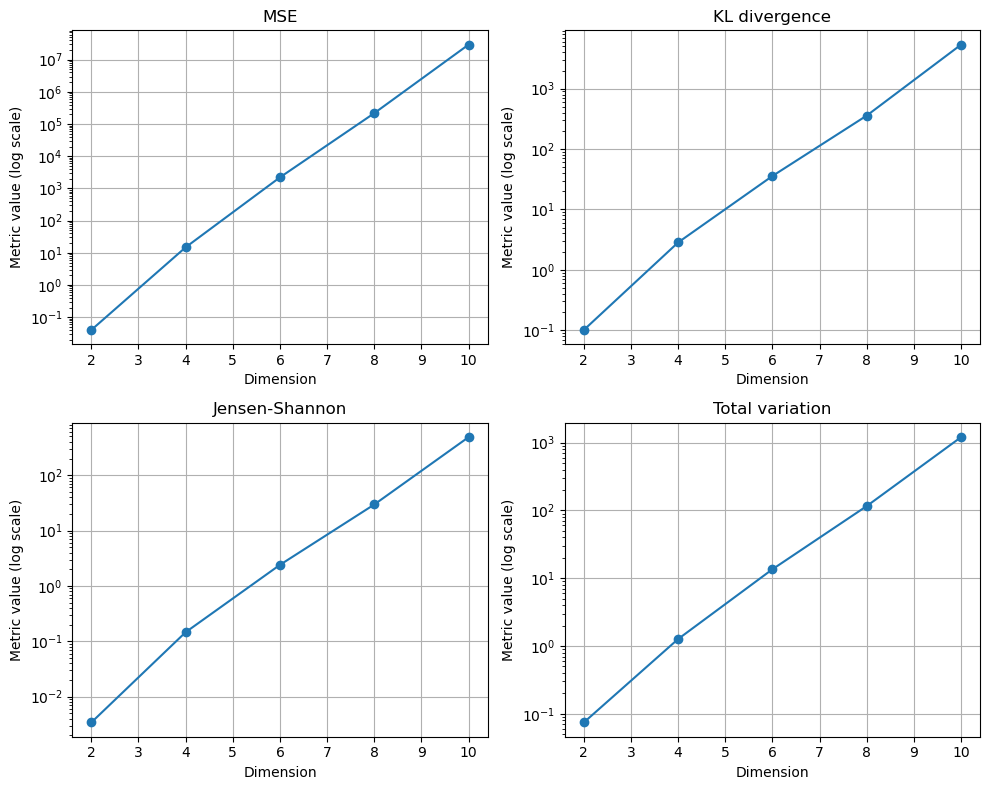

In [52]:
dims = np.arange(2, 11, 2, dtype=int)
mse_list, kl_list, js_list, tv_list = [], [], [], []

for d in dims:
    density = generate_density(d, random_state=random_state)
    X_all     = sample_from_density(density, d, N + 500, random_state=random_state)
    X_train_d = X_all[:N]
    X_val_d   = X_all[N:]

    # estimate of h for each dim using cross validation:
    params = {'bandwidth': np.logspace(-2, 2, 30)}
    grid   = GridSearchCV(KernelDensity(kernel='gaussian'), params, cv=5, n_jobs=-1)
    grid.fit(X_train_d)
    h = grid.best_params_['bandwidth']

    est_dens = parzen_density(X_train_d, h)

    mse, kl, js, tv = compute_metrics(
        density, est_dens, sample_from_density, dim=d, n_eval=20000
    )
    mse_list.append(mse)
    kl_list.append(kl)
    js_list.append(js)
    tv_list.append(tv)

plot_metrics(dims, mse_list, kl_list, js_list, tv_list)

Efectivamente, esto se comprueba. Cuanto mayor es la dimensión, mayor es la cantidad de espacio vacío y, por tanto, mayores son estas métricas de distancia y divergencia. 

No debería pasar lo mismo al aumentar las muestras. Lo normal al hacer eso con una dimensión fija es que el espacio se vaya llenando. Tal vez podamos notar que la forma de esta curva no es monótona decreciente por culpa del efecto de la aleatoriedad al crear muestras, pero, en general, cuando $N$ crezca lo suficiente, el espacio se llenerá y las métricas disminuirán (si miden promedios, como es el caso de las 4 que se prueban). 



c. Con un número de muestra fija, si aumenta la dimensión ¿$h$ óptimo crece o decrece?

d. Con una dimensión fija, al aumentar el número de muestra  ¿$h$ óptimo crece o decrece?

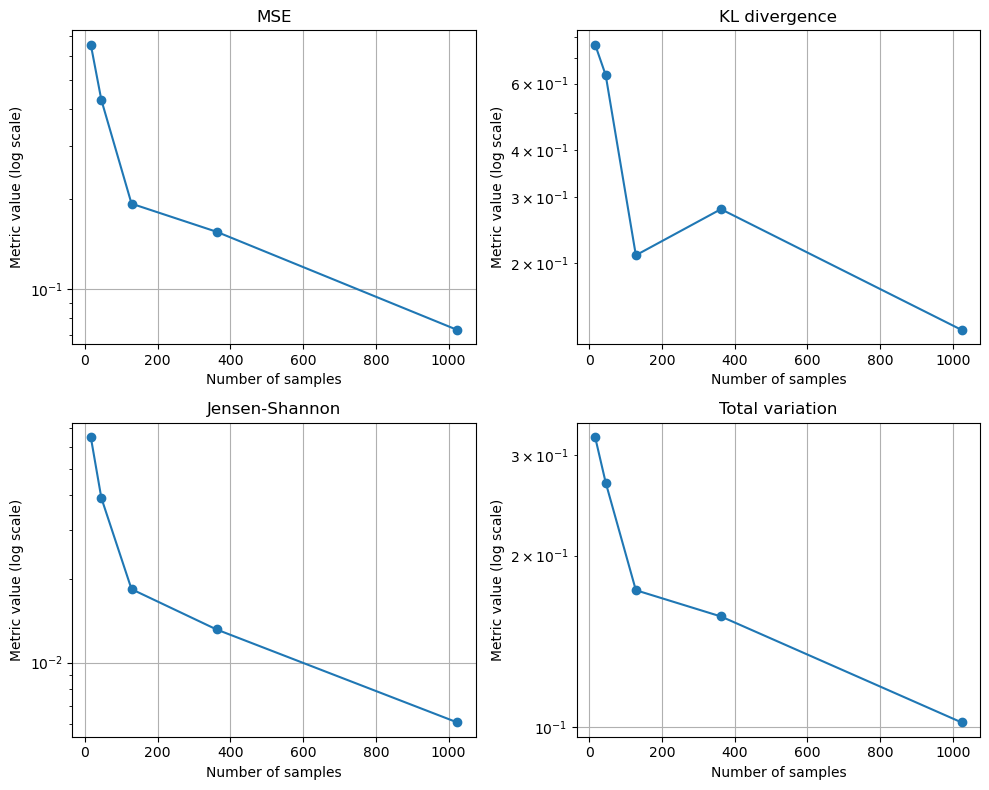

In [53]:
# dimensión fija y aumentamos muestras
dim = 2
num_samples_list = np.logspace(2, 5, num=5, base=4, dtype=int)  

mse_list = []
kl_list = []
js_list = []    
tv_list = []

for num_samples in num_samples_list:
    
    density = generate_density(dim, random_state=random_state)
    X = sample_from_density(density, dim, num_samples)

    # estimate of h for each dim using cross validation:
    params = {'bandwidth': np.logspace(-2, 2, 30)}
    grid   = GridSearchCV(KernelDensity(kernel='gaussian'), params, cv=5, n_jobs=-1)
    grid.fit(X)
    h = grid.best_params_['bandwidth']

    est_density = parzen_density(X, h)

    mse, kl, js, tv = compute_metrics(density, est_density, sample_from_true_density=sample_from_density, dim=dim, n_eval=20000)

    mse_list.append(mse)
    kl_list.append(kl)
    js_list.append(js)
    tv_list.append(tv)

plot_metrics(num_samples_list, mse_list, kl_list, js_list, tv_list, samples=True)

Con esto podemos comprobar que, efectivamente, cuando $N$ crece lo suficiente, en general, las métricas disminuyen, pues tienden a rellenar el espacio vacío en el plano ($dim=2$). Referencias para esta sección: Silverman, B. W. (1986), Sheather, S. J. (2004).

Nota: estos resultados ocurren debido a que $h$ se seleccionó adecuadamente. De no haberse elegido usando la más segura de entre las 3 formas, podríamos haber obtenido resultados muy incoherentes. 

## Ejercicio 2

¿Como utilizarías la estimación de densidad para resolver el siguiente problema de regresión?

Pista: 

Resolver un problema de regresión es equivalente a en estimar la **densidad conjunta** de las variables de entrada y salida: $$P(X, Y)$$ utilizando un estimador de densidad como **Parzen windows (KDE)**. Una vez estimada la densidad conjunta, podemos obtener la **densidad condicional**: $$P(Y \mid X) = \frac{P(X,Y)}{P(X)}$$ A partir de esta distribución condicional podemos construir una función de regresión.

Existen varias estrategias posibles:

#### 1. Estimación por máxima probabilidad (MAP).  (0-1 loss)

Se predice el valor de $y$ que maximiza la probabilidad conjunta:

$f(x) = \arg\max_y P(x, y)$

Esto consiste en buscar el valor de $y$ que hace más probable el par $(x,y)$ según la densidad estimada.

#### 2. Regresión por esperanza condicional (MSE)

Otra opción es usar el valor esperado de $Y$ dado $X$:

$f(x) = \mathbb{E}[Y \mid X]$

En la práctica se aproxima evaluando la densidad conjunta en distintos valores de $y$ y calculando la media ponderada.

#### 3. Mediana condicional (MAE)

$m : X \longrightarrow Y$ se calcula como el valor tal que $P(Y \leq m(x) \mid X=x) = 0.5$

Implementa al menos una de ella. 

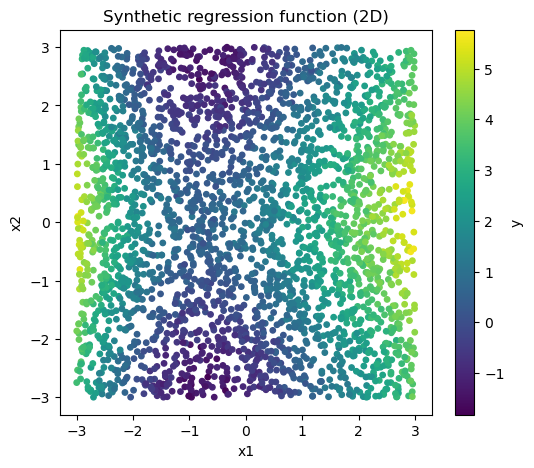

In [54]:
# Ejemplo de código para generar y visualizar datos de regresión en 2D utilizando Python y Matplotlib.
import matplotlib.pyplot as plt
from utils.generate_regression_data import generate_regression_data
# ---- generate 2D data ----
X, y = generate_regression_data(
    n_samples=3000,
    dim=2,
    noise=0.2,
    random_state=0
)

# ---- plot ----
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=y, cmap="viridis", s=15)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Synthetic regression function (2D)")
plt.colorbar(label="y")
plt.show()

Nota: en la implementación de DensityRegression, el método privado eval_grid fija $x$ y barre para todos los posibles valores de $y$. Esto es en realidad equivalente a $$P(Y|X=x)$$ salvo por un factor de escala:  $$P(Y|X=x) = \frac{P(X=x, Y=y)}{P(X=x)}$$ que por lo general no afectará demasiado pues al maximizar obtendremos resultados equivalentes.

In [ ]:
from models.DensityRegression import DensityRegression
from sklearn.metrics import r2_score, mean_squared_error

density_regressor = DensityRegression()
density_regressor.fit(X, y);

#### 1. Estimación por máxima probabilidad (MAP).  (0-1 loss)

Este método consiste en seguir la idea expresada antes para calcular $$P(Y|X=x)$$ y encontrar un $y$ que lo maximiza (Bishop, C. M. (2006)):

$$ \operatorname{arg max}_y P(Y|X=x) = \operatorname{arg max}_y \frac{P(X=x, Y=y)}{P(X=x)} = \operatorname{arg max}_y P(X=x, Y=y)$$

Es aquí, por ejemplo, donde podemos notar que el factor de escala no influye a la hora de calcular $$P(Y|X=x)$$

In [56]:
y_pred_map = density_regressor.predict_map(X)
print("R^2 Score:", r2_score(y, y_pred_map))
print("Mean Squared Error:", mean_squared_error(y, y_pred_map))

R^2 Score: 0.9524935626482546
Mean Squared Error: 0.133890851874512


#### 2. Regresión por esperanza condicional (MSE)

Este método consiste en usar la definición matemática de la esperanza condicional (Bishop, C. M. (2006)):

$$\mathbb{E}[Y|X=x] = \int y P(Y=y|X=x) dy$$

Teniendo en cuenta que $P(Y|X) = \frac{P(X=x, Y=y)}{P(X=x)}$, podemos marginalizar la $P(X)$: $$P(X=x) = \int P(X=x, Y=y)dy $$ y obtener:

$$ \mathbb{E}[Y|X=x] = \frac{\int y P(Y=y_i, X=x) dy}{\int P(X=x, Y=y)dy} $$

Y ahora si discretizamos el problema para hacerlo viable computacionalmente obtendremos una aproximación a esta esperanza condicionada:

$$ \mathbb{E}[Y|X=x] = \frac{\sum_{i=1}^G y_i P(Y=y_i, X=x)}{\sum_{i=1}^G P(X=x, Y=y_i)} $$

In [57]:
y_pred_mean = density_regressor.predict_mean(X)
print("R^2 Score:", r2_score(y, y_pred_mean))
print("Mean Squared Error:", mean_squared_error(y, y_pred_mean))

R^2 Score: 0.9439900268329787
Mean Squared Error: 0.15785698610223184


#### 3. Mediana condicional (MAE)

Se puede demostrar que la mediana es el valor de $y$ que minimza el error absoluto esperado:

$$ y^* = \operatorname{argmin_c} \mathbb{E[\left|Y-c\right| \left| X=x\right]} = \int |y-c|P(X=x, Y=y)dy $$

Derivando respecto de c e igualando a cero:

$$ \frac{\partial}{\partial c} \int |y-c|P(X=x, Y=y)dy = \int_{-\infty}^c P(X=x, Y=y)dy - \int_{c}^{\infty} P(X=x, Y=y) dy = 0  \iff $$
$$ \iff P(Y\leq c | X=x) = P(Y>c \ X=x) = 0.5  \text{ (la mediana)}$$

Por tanto la idea es encontrar aquel $y$ que satisface $P(y^*|X=x) = 0.5$, tal y como se implementa en el archivo DensityRegression.py. 

In [58]:
y_pred_median = density_regressor.predict_mean(X)
print("R^2 Score:", r2_score(y, y_pred_median))
print("Mean Squared Error:", mean_squared_error(y, y_pred_median))

R^2 Score: 0.9439900268329787
Mean Squared Error: 0.15785698610223184


Nota: de igual forma que se puede demostrar que la mediana es el valor de $y^*$ que minimiza el error absoluto medio, se puede demostrar que la media es el valor de $y$ que minimiza el error cuadrático medio (Bishop, C. M. (2006), secciones 1.1 para la esperanza condicionada y 5.6 para la mediana): 

$$ y^* = \mathbb{E}[(Y-c)^2 | X=x] = \int (y-c)^2 P(Y=y | X=x) dy $$

Derivando e igualando a cero:

$$ \frac{\partial}{\partial c} \int (y-c)^2 P(Y=y | X=x) dy = \int -2(y-c) P(Y=y|X=x)dy = 0 \iff $$

$$ \iff \int y P(Y=y|X=x)dy = c \int P(Y=y|X=x)dy$$

Por definición: 

$$\int P(Y=y|X=x)dy = 1$$

Y

$$ \int y P(Y=y|X=x)dy = \mathbb{E}[Y|X=x] $$

Por lo que:

$$c = \mathbb{E}[Y|X=x]$$

# Ejercicio 3


Responda razonadamente: ¿Cuál es la ventaja de usar distribuciones de la familia exponencial en un
modelo de mezcla de distribuciones para la estimación de parámetros
mediante el algoritmo de *expectation-maximization* (EM)?


**Pista:** Supongamos que el modelo de mezcla pertenece a la familia exponencial y tiene la forma:

$$
p(x_n \mid z_n = k, \eta_k) = h(x_n)\exp\left(\eta_k^T T(x_n) - A(\eta_k)\right), 
\quad k = 1,\dots,K
$$

donde:

- $\eta_k$ son los **parámetros naturales** de la componente $k$  
- $T(x_n)$ son los **estadísticos suficientes**  
- $A(\eta_k)$ es el **logaritmo de la función de partición**  
- $h(x_n)$ es la **medida base**

Supongamos además un **prior categórico** sobre la variable latente:

$$
p(z_n = k \mid \pi) = \pi_k, \qquad \sum_{k=1}^K \pi_k = 1
$$

Calcula la verosimilitud  y partir de este modelo:

1. Calcula el **paso E** del algoritmo EM, obteniendo las responsabilidades

$$
\gamma_{nk} = p(z_n = k \mid x_n, \eta^{old}, \pi^{old})
$$

2. Calcula el **paso M**, maximizando la esperanza de la log-verosimilitud completa para obtener las actualizaciones de:

- $\pi_k$
- $\eta_k$

# 1.2 Ilustra la respuesta con un ejemplo usando modelos de mezcla de gaussianas

$$p(x) = \sum_{k=1}^K \pi_k \mathcal{N}(x|\mu_k, \sigma_k^2) $$

## Solución ejercicio 3

Por conveniencia para el lector y para nosotros, plantearemos el problema desde el principio para no perder el hilo: 

Se pretende identificar de qué gaussiana proviene una muestra concreta de un conjunto de muestras $$X=\{x_1, x_2, \cdots, x_N\}$$ que ha sido obtenida de un modelo muestra de $K$ gaussianas. Para ello, se introducen las variables latentes $$z_n \in \{1, 2, \cdots, K\}$$ que indican de qué componente proviene una observación $x_n$. Planteamos el modelo generativo de la forma $$ P(x_n | z_n = k; \theta) = \frac{1}{(2\pi)^(\frac{D}{2})\left| \Sigma \right|^{\frac{1}{2}}}exp[-\frac{1}{2}(x_n-\mu_k)^T\Sigma_k^{-1}(x_n-\mu_k)]$$  donde $\theta$ representa al espacio de parámetros $$\theta=\{\mu_k, \Sigma_k, \pi_k\}_{k=1}^K$$ Además, asume un prior sobre la variable latente: $$ P(z_n=k | \pi) = \pi_k, \ \ \ \sum_{k=1}^K \pi_k = 1$$

Al tratar de maximizar la verosimilitud, obtendríamos el logaritmo de una suma. Se puede demostrar que esto no tiene solución analítica cerrada, por lo que se diseñó el algoritmo EM que rodea el problema precisamente introduciendo estas variables latentes $Z$ y trabajando con la verosimilitud conjunta $P(X, Z | \theta)$. La idea es instroducir una distribución auxiliar $q(z)$ sobre las variables latentes y descomponer su log-verosimilitud: 

$$log P(X | \theta) = \operatorname{log} \int P(X,Z \theta) dZ = \operatorname{log} \int q(Z) \frac{P(X,Z \theta)}{q(Z)} dZ \overset{\text{def}}{\equiv} \operatorname
{log} \mathbb{E}_{q(z)}\left[ \frac{P(X,Z | \theta)}{q(z)}\right] \overset{\text{def}}{\equiv} \mathbb{E}_{q(z)}\left[ \operatorname{log} \frac{P(X,Z | \theta)}{q(z)}\right] + KL(q(z) || P(Z | X, \theta)) \text{ (ELBO + Divergencia Kullback-Leibler)}$$

Maximizar el ELBO respecto de $q$ es equivalente a minimizar la divergencia de Kullback-Leibler respecto de $q$. Ese mínimo se encuentra en $q(z) = P(Z | X, \theta)$. En ese punto, el ELBO coincide exactamente con $\operatorname{log}P(X | \theta)$. Es aquí donde entra el algoritmo EM (expectation-minimization) ([3] Bishop, C. M. (2006)):

#### Expectación: 

En este paso el objetivo es calcular las responsabilidades de cada componente $k$ sobre cada muestra $x_n$. Para ello, supondremos que las muestras son independientes e idénticamente distribuidas (iid) y entonces:

$$q(z) = P(Z | X, \theta ) = \prod_{n=1}^N P(z_n | x_n, \theta ) $$

Y ahora aplicando el Teorema de Bayes, calculamos para cada muestra cual es su probabilidad para cada componente $k$. Para eso, usaremos el prior categórico supuesto al principio: 

$$P(z_n = k | x_n, \theta) = \frac{\pi_k \mathcal{N}(x_n | \mu_k, \Sigma_k)}{\sum_{k'=1}^K} \pi_{k'} \mathcal{N}(x_n | \mu_{k'}, \Sigma_{k'})$$

Y llamaremos a esto $r_{nk}$, que puede ser interpretado como la probabilidad de que la muestra $x_n$ provenga de la componente gaussiana $k$. Lógicamente $\sum_k r_{nk} = 1 $ para cada $n$ ([3] Bishop, C. M. (2006)). 

#### Minimización: 

Es en este paso del algoritmo donde podemos responder a la pregunta planteada, acerca de por qué usaremos distribuciones de la familia exponencial para la estimación de los parámetros. En cada paso se actualizan los parámetros. La idea es que, habiendo fijado $q(z) = P(Z | X, \theta)$, $\operatorname{log}(P(X|\theta) = ELBO)$, por lo que bastaría con maximizar el $ELBO$ con respecto a $\theta$ en la iteración $i$, que denotaremos por $\theta^{(i)}$ obteniendo un $\theta$ actualizado, que denotaremos por $\theta^{(i+1)}$. Para maximizar el $ELBO$, en este paso, $q(z)$ ya es fija. Entonces:

$$ELBO = \mathbb{E}_{q(z)}[\operatorname{log}\frac{P(X, Z | \theta)}{q(z)}] = \mathbb{E}_{q(z)}[\operatorname{log}P(X, Z | \theta)] + \mathbb{E}_{q(z)}[-\operatorname{log}q(z)] $$

Que es equivalente a maximizar $\mathbb{E}_{q(z)}[\operatorname{log}P(X, Z | \theta)]$, puesto que $\mathbb{E}_{q(z)}[-\operatorname{log}q(z)]$ no depende de $\theta$. Y podemos escribir esto en términos de las responsabilidades $r_{nk}$:

$$\mathcal{Q}(\theta) = \mathbb{E}_{q(z)}[\operatorname{log}P(X, Z | \theta)] = \sum_{n=1}^N \sum_{k=1}^K r_{nk}[\operatorname{log}(\pi_k) + \operatorname{log} \mathcal{N}(x_n | \mu_k, \Sigma_k)]$$

Como la gaussiana pertenece a la familia exponencial, su log tiene la forma:

$$ \operatorname{log} \mathcal{N}(x_n | \mu_k, \Sigma_k) = \operatorname{log} h(x_n) + \eta_k^T T(x_n) - A(\eta_k) $$

En concreto, pertenece con los siguientes parámetros (parámetros naturales, estadísticas suficientes y función de partición) ([4] Wainwright, M. J., & Jordan, M. I. (2008)): 

$$ 
\eta_k = \begin{pmatrix} 
\Sigma_k^{-1}\mu_k \\
-\frac{1}{2} \Sigma_k^{-1}
\end{pmatrix}, \ \ \  
T(x_n) = \begin{pmatrix} 
x_n \\
x_n x_n^T
\end{pmatrix}, \ \ \ 
A(\eta_k) = \frac{1}{2} \mu_k^T \Sigma_k^{-1}\mu_k + \frac{1}{2}\log\left| \Sigma_k \right| 
$$

Por tanto, sustituyendo estos parámetros en $\mathcal{Q}$ obtendremos: 

$$\mathcal{Q}(\theta) = \sum_{n=1}^N \sum_{k=1}^K r_{nk}[\operatorname{log}(\pi_k) + \operatorname{log} h(x_n) + \eta_k^T T(x_n) - A(\eta_k)]$$

El objetivo es encontrar los parámetros $\pi_k$, $\mu_k$ y $\Sigma_k$ óptimos. Para ello, bastaría con derivar con respecto de $\eta_k$. Encontraremos primero la solución para $\pi_k$ y posteriormente para $\mu_k$ y $\Sigma_k$: 

$$\mathcal{Q}(\theta) = \sum_{k=1}^{K} \sum_{n=1}^{N} r_{nk} \left[ \log(\pi_k) + \log(h(x_n)) + \eta_k^T T(x_n) - A(\eta_k) \right]$$

$$= \underbrace{\sum_{n=1}^{N} \sum_{k=1}^{K} r_{nk} \log \pi_k}_{\mathcal{Q}_\pi} + \underbrace{\sum_{n=1}^{N} \sum_{k=1}^{K} r_{nk} \left[ \log h(x_n) + \eta_k^T T(x_n) - A(\eta_k) \right]}_{\mathcal{Q}_{\mu, \Sigma}}$$

#### Maximización de los parámetros $\pi_k$

$$\mathcal{Q}_\pi = \sum_{n=1}^{N} \sum_{k=1}^{K} r_{nk} \log \pi_k, \qquad \sum_k \pi_k = 1$$

Introducimos el multiplicador de Lagrange para este problema:

$$\mathcal{L}(\pi, \lambda) = \sum_{n=1}^{N} \sum_{k=1}^{K} r_{nk} \log \pi_k - \lambda \left( \sum_{k=1}^{K} \pi_k - 1 \right)$$

Derivando e igualando a cero (condición de óptimo local):

$$\nabla_{\pi_k} \left[ \mathcal{L}(\pi, \lambda) \right] = \frac{\sum_{n=1}^{N} r_{nk}}{\pi_k} - \lambda = 0 \implies \pi_k^* = \frac{N_k}{\lambda}$$

Y como sabemos que:

$$\sum_{k=1}^{K} \frac{N_k}{\lambda} = 1 \implies \lambda = \sum_{k=1}^{K} N_k = N$$

Y por tanto:

$$\boxed{\pi_k^* = \frac{N_k}{N}} \quad \text{(trivial)}$$

#### Maximización de los parámetros $\mu_k$, $\Sigma_k$

Por sencillez, podemos maximizar $\eta_k$ de forma equivalente a maximizar $\mu_k, \Sigma_k$ de forma conjunta, puesto que, recordamos que:

$$\eta_k = \begin{pmatrix} \Sigma_k^{-1} \mu_k \\ -\frac{1}{2} \Sigma_k^{-1} \end{pmatrix}$$

Por lo tanto, sabiendo que $\mathcal{Q}_{\mu_k, \Sigma_k}$ es:

$$\mathcal{Q}_{\mu,\Sigma} = \sum_{n=1}^{N} \sum_{k=1}^{K} r_{nk} \left[ \log h(x_n) + \eta_k^T T(x_n) - A(\eta_k) \right]=$$

$$= \sum_{n=1}^{N} \sum_{k=1}^{K} r_{nk} \left[ \log h(x_n) \right] + \sum_{k=1}^{K} \left( \eta_k^T \sum_{n=1}^{N} r_{nk} T(x_n) - N_k A(\eta_k) \right)$$

Derivando con respecto a $\eta_k$ e igualando a cero:

$$\nabla_{\eta_k} \left[ \mathcal{Q}_{\mu,\Sigma} \right] = \sum_{n=1}^{N} r_{nk} T(x_n) - N_k \frac{\partial A(\eta_k)}{\partial \eta_k} = 0$$

$$\iff \frac{\partial A(\eta_k)}{\partial \eta_k} = \frac{\sum_{n=1}^{N} r_{nk} T(x_n)}{N_k}$$

Para cualquier función de la familia exponencial se verifica que ([4] Wainwright, M. J., & Jordan, M. I. (2008)):

$$\frac{\partial A(\eta_k)}{\partial \eta_k} = \mathbb{E}_{P(x|\eta_k)}\left[ T(x) \right] = \frac{\sum_{n=1}^{N} r_{nk} T(x_n)}{N_k}$$

Esto implica que $\frac{\partial A(\eta_k)}{\partial \eta_k}$ es monótona e invertible, por lo que:

$$\boxed{\eta_k^* = \left( \frac{\partial A(\eta_k)}{\partial \eta_k} \right)^{-1} \left( \frac{\sum_{n=1}^{N} r_{nk} T(x_n)}{N_k} \right)}$$

Esto permite solo calcular los parámetros en cada iteración de EM, en lugar de tener que hacer una optimización de $\mathcal{Q}$ en cada paso.

Al final del algoritmo, obtendremos:

$$\theta^* = \{ \pi_k, \mu_k, \Sigma_k \} \quad \text{y} \quad r_{nk}$$

Y podremos saber con qué certeza proviene cada muestra $x_n$ a la gaussiana $k$:

$$k^*(x_n) = \underset{k}{\operatorname{arg\,max}} \; r_{nk}$$

De no existir esta solución analítica cerrada, no tendríamos garantía de convergencia monótona ([4] Wainwright, M. J., & Jordan, M. I. (2008)).

Por supuesto, este $k^*$ codificado usando one-hot nos devolvería una matriz $N\times K$ de la forma $$(e_1, e_2, \cdots, e_N)^T$$ con vectores fila $e_n, \ \ (1 \times K)$ con un 1 en la posición del $k^*$ para esa muestra $n$ y un 0 en el resto de posiciones. Para esto, hay que aceptar la interpretación de cada responsabilidad como una probabilidad de pertenencia a cada gaussiana. 

- - - - 

Referencias: 

- La referencia principal e imprescindible para esta parte es [3] Bishop, C. M. (2006). El capítulo 9 cubre prácticamente todo. 

- Para la conexión con la familia exponencial, [4] Wainwright, M. J., & Jordan, M. I. (2008), cubre en profundidad por qué la familia exponencial hace tratable el paso M y la propiedad de que $\frac{dA}{d\eta}$​ es invertible.

- Para la derivación del ELBO y algunos de los resultados teóricos en relación con el algoritmo EM [5] Neal, R. M., & Hinton, G. E. (1998). 

- Como complemeneto más accesible, [6] Murphy, K. P. (2022). 

#### A continuación, se ilustrará todo lo mostrado en la celda anterior (la matemática) a partir de un ejemplo:

In [59]:
from em import e_step, m_step, log_likelihood

np.random.seed(42)
K = 3       # número de gaussianas
N = 300     # número de muestras
D = 2       # dimensión


pi_true  = np.array([0.3, 0.5, 0.2])
mu_true  = np.array([[0, 0], [5, 5], [0, 8]], dtype=float)
cov_true = np.array([
    [[1.0, 0.0], [0.0, 1.0]],
    [[1.5, 0.5], [0.5, 1.5]],
    [[1.0, 0.0], [0.0, 2.0]]
])

z_true = np.random.choice(K, size=N, p=pi_true)
X = np.array([
    np.random.multivariate_normal(mu_true[k], cov_true[k])
    for k in z_true
])

pi  = np.ones(K) / K
mu  = X[np.random.choice(N, K, replace=False)]
cov = np.array([np.eye(D)] * K)

In [60]:
n_iters = 50
ll_hist = []

for i in range(n_iters):
    R             = e_step(X, pi, mu, cov)
    pi, mu, cov   = m_step(X, R)
    ll_hist.append(log_likelihood(X, pi, mu, cov))

R_final   = e_step(X, pi, mu, cov)
k_pred    = np.argmax(R_final, axis=1)
precision = np.mean(k_pred == z_true)   # las etiquetas pueden estar permutadas, como se explica luego

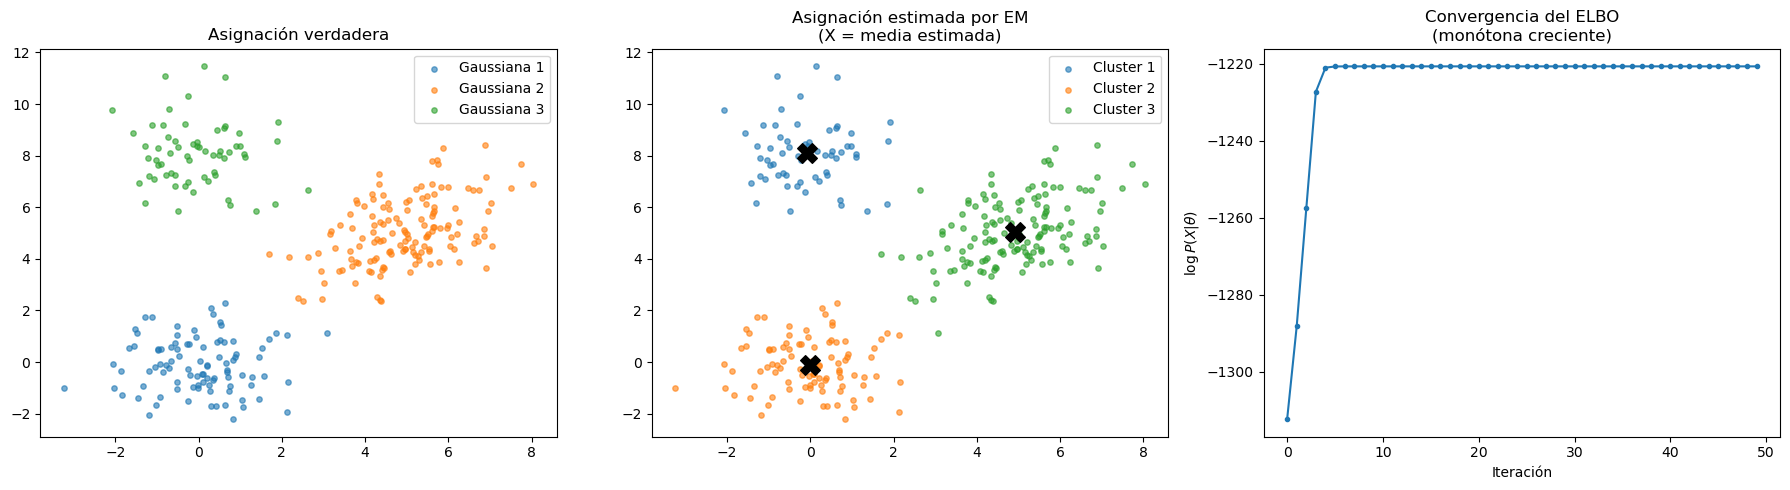

In [61]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
for k in range(K):
    ax.scatter(X[z_true==k, 0], X[z_true==k, 1], s=15, alpha=0.6, label=f'Gaussiana {k+1}')
ax.set_title('Asignación verdadera')
ax.legend()

ax = axes[1]
colors = ['tab:blue', 'tab:orange', 'tab:green']

for k in range(K):
    ax.scatter(X[k_pred==k, 0], X[k_pred==k, 1], s=15, alpha=0.6,
               color=colors[k], label=f'Cluster {k+1}')

for k in range(K):
    ax.scatter(*mu[k], marker='X', s=200, color='black', zorder=5)
ax.set_title('Asignación estimada por EM\n(X = media estimada)')
ax.legend()

ax = axes[2]
ax.plot(ll_hist, marker='o', markersize=3)
ax.set_xlabel('Iteración')
ax.set_ylabel('$\\log P(X|\\theta)$')
ax.set_title('Convergencia del ELBO\n(monótona creciente)')

plt.tight_layout()
plt.show()

## Resultados

Se han generado $N=300$ muestras a partir de una mezcla de $K=3$ gaussianas bidimensionales con parámetros verdaderos $\{\pi_k, \mu_k, \Sigma_k\}_{k=1}^3$ conocidos, lo que permite evaluar la calidad de la estimación de forma cuantitativa.

La gráfica de la derecha muestra la evolución de $\log P(X|\theta)$ a lo largo de las iteraciones. Se observa que la log-verosimilitud es **estrictamente monótona creciente** y converge en menos de 10 iteraciones. Esto no es una casualidad — es la consecuencia directa de que la gaussiana pertenece a la familia exponencial, lo que garantiza que el paso M tiene solución analítica cerrada y encuentra el **máximo global exacto** de $\mathcal{Q}(\theta)$ en cada iteración. Esta exactitud es la que sostiene la demostración de convergencia monótona:

$$\log P(X|\theta^{i+1}) \geq \text{ELBO}(\theta^{i+1}) \geq \text{ELBO}(\theta^{i}) = \log P(X|\theta^{i})$$

Si el paso M no tuviera solución cerrada — es decir, si $P(x|\theta)$ no perteneciera a la familia exponencial — el máximo de $\mathcal{Q}(\theta)$ tendría que aproximarse mediante optimización numérica iterativa. En ese caso la segunda desigualdad $\text{ELBO}(\theta^{i+1}) \geq \text{ELBO}(\theta^{i})$ dejaría de estar garantizada, y la log-verosimilitud podría decrecer entre iteraciones. La curva de la derecha podría
dejar de ser monótona, y con ello perderíamos toda garantía de que el algoritmo está progresando hacia un máximo. En la práctica esto se traduce en algoritmos que oscilan, divergen, o convergen a puntos que no son ni siquiera máximos locales de la verosimilitud.

La monotonicidad que se observa en la gráfica es por tanto evidencia empírica directa de por qué la elección de la familia exponencial no es arbitraria, sino la condición que hace que EM sea un algoritmo correcto.

La gráfica central muestra la asignación estimada por EM junto con las medias estimadas (marcadas con X). Comparando con la asignación verdadera (izquierda), el algoritmo recupera correctamente la estructura de las tres componentes. Las pequeñas discrepancias en las fronteras entre clusters corresponden a puntos con responsabilidades ambiguas — es decir, puntos para los que $r_{nk}$ no está concentrada en una sola componente, lo cual es información que un algoritmo de asignación dura como K-means perdería.

Nota: Los parámetros estimados coinciden con los verdaderos salvo una permutación de índices, lo cual es un resultado esperado: la función de verosimilitud tiene $K! = 6$ máximos globales equivalentes por simetría, correspondientes a las distintas formas de etiquetar las $K$ componentes. Esto no es un fallo del algoritmo sino una propiedad estructural del modelo de mezclas.

### Ejercicio 4: Relación con modelos de mezcla

Los estimadores de densidad basados en ventanas de Parzen pueden interpretarse como un caso particular de **modelo de mezcla**, donde cada muestra genera un componente del modelo.

En particular, el estimador de Parzen puede escribirse como

$$
\hat p(x) =
\frac{1}{N}\sum_{n=1}^{N}
\frac{1}{h^D}
K\left(\frac{\|x-x_n\|_2}{h}\right)
$$

lo cual puede interpretarse como un **modelo de mezcla con $N$ componentes**, donde:

- cada componente está centrado en un dato $x_n$,
- todos los componentes tienen el mismo ancho de banda $h$,
- y los pesos de mezcla son iguales.

1. Explique por qué el estimador de Parzen puede interpretarse como un **modelo de mezcla de distribuciones**.

2. Compare esta formulación con un **modelo de mezcla de gaussianas (GMM)** aprendido a partir de los datos.  
   ¿Cuál es la diferencia entre ambos enfoques en términos de:

   - número de componentes
   - parámetros aprendidos
   - flexibilidad del modelo?

Solución: 

Un estimador de Parzen puede interpretarse como un modelo de mezcla de distribuciones en el caso de que cada muestra de la distribución empírica $\mathcal{D} = \{x_n\}_{n=1}^N$ se corresponda con una distribución (preferiblemente simétrica) cuya varianza venga dada en términos del ancho de banda de las ventanas de Parzen. Dicho de otra forma, la densidad de Parzen puede corresponderse con un caso particular de mezcla de $N$ distribuciones en el que se cumplen ciertas características:

- Todos los puntos tienen el mismo peso. Es decir, para un modelo de mezcla de gaussianas de la forma $$ \sum_k \pi_k \mathcal{N}(\mu_k, \Sigma_k)$$ los pesos $\pi_k$ tienen que valer todos lo mismo: $$\sum_{k=1}^N \pi_k = 1, \ \ \pi_1 = \pi_2 = \cdots = \pi_k, \forall k = \{1, 2, \cdots, N\}$$ Y esto implicaría que $$\sum_{k=1}^N \pi_k = N \pi_k = 1 \iff \pi_k = \frac{1}{N}, \ \forall k = \{1, 2, \cdots, N\}$$ Esto es relevante a la hora de codificar el algoritmo EM, puesto que podemos suponer un prior uniforme para las variables latentes: $$P(z=n) = \frac{1}{N}$$ Y por tanto simplificar en gran medida el cálculo de responsabilidades: $$r_{nk} = \frac{\frac{1}{N}\mathcal{K}(x | x_n, h)}{\sum_{n'=1}^N\frac{1}{N}\mathcal{K}(x | x_{n'}, h)} = \frac{\mathcal{K}(x | x_n, h)}{\sum_{n'=1}^N\mathcal{K}(x | x_{n'}, h)}$$

- En un modelo de mezcla de gaussianas, por ejemplo, esto no tiene por qué ocurrir, cada componente tiene su propia matriz de covarianzas $\Sigma_k$. Pero en un estimador de Parzen todos las distribuciones tienen la misma varianza, que además depende del ancho de banda del estimador, $h$. 

- En Parzen los parámetros no se aprenden. Tan solo se tiene un ancho de banda $h$ como hiperparámetro que se ajusta a los datos y el número de componentes o ventanas de Parzen crece linealmente con $N$. Esto convierte al algoritmo EM aplicado sobre estimadores de Parzen en un caso degenerado de este algoritmo, pues no existiría el paso M, no habiendo un conjunto de parámetros a optimizar. 

### Ejercicio 5: Verosimilitud no acotada en modelos de mezcla

En los **modelos de mezcla de gaussianas**, los parámetros del modelo se estiman normalmente mediante **máxima verosimilitud**, por ejemplo utilizando el algoritmo EM.

Sin embargo, la función de verosimilitud de un modelo de mezcla **no está acotada superiormente**. En particular, si no se impone ninguna restricción sobre las varianzas de las componentes, puede ocurrir el siguiente fenómeno:

- una componente gaussiana puede **colapsar sobre un único punto de la muestra**,  
- haciendo que su varianza tienda a cero,
- lo que provoca que la densidad en ese punto tienda a infinito.

Como consecuencia, la **verosimilitud del modelo puede hacerse arbitrariamente grande**, lo que produce soluciones degeneradas.

1. Explique por qué una gaussiana cuya varianza tiende a cero alrededor de un punto de la muestra produce una verosimilitud arbitrariamente grande.

2. Realice un pequeño experimento con un **modelo de mezcla de gaussianas**, mostrando cómo una componente puede concentrarse alrededor de uno o pocos puntos.

3. Discuta qué estrategias se utilizan en la práctica para evitar este problema, por ejemplo:

- regularización de las covarianzas
- límites inferiores en la varianza
- priors bayesianos
- inicialización adecuada del algoritmo EM

Solución

1. Una gaussiana con varianza cero sería técnicamente una delta de Dirac. Esto implicaría que, matemáticamente, el estimador de Parzen evaluado en en el punto correspondiente a la media de esa componente, tendería a infinito. Esto no es así en la práctica, pues no podrían computarse estos límites teóricos, pero, sin embargo, sí que se haría arbitrariamente grande, produciendo soluciones degeneradas. 

In [62]:
np.random.seed(42)
N = 100
X = np.concatenate([
    np.random.multivariate_normal([0, 0], np.eye(2), N//2),
    np.random.multivariate_normal([6, 6], np.eye(2), N//2)
])

K  = 3
pi = np.ones(K) / K
mu = np.array([
    [0.0, 0.0],
    [X[5, 0], X[5, 1]],   # encima de un punto -> colapso
    [6.0, 6.0],
])
cov = np.array([np.eye(2)] * K)

In [63]:
n_iters  = 30
ll_hist  = []
var_hist = []

for i in range(n_iters):
    R           = e_step(X, pi, mu, cov)
    pi, mu, cov = m_step(X, R, eps=0)   # sin restricción → colapso
    ll_hist.append(log_likelihood(X, pi, mu, cov))
    var_hist.append(np.linalg.det(cov[1]))

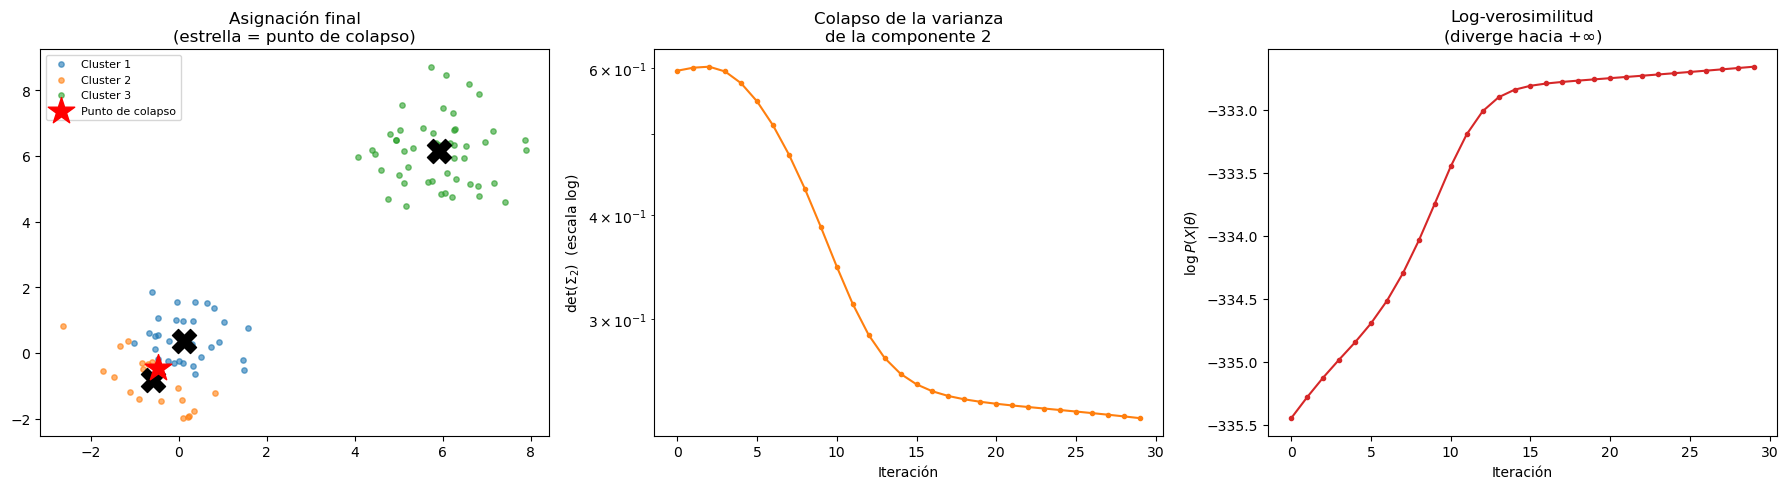

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
k_pred = np.argmax(e_step(X, pi, mu, cov), axis=1)
colors = ['tab:blue', 'tab:orange', 'tab:green']
for k in range(K):
    ax.scatter(X[k_pred==k, 0], X[k_pred==k, 1],
               s=15, alpha=0.6, color=colors[k], label=f'Cluster {k+1}')
for k in range(K):
    ax.scatter(*mu[k], marker='X', s=300, color='black', zorder=5)
ax.scatter(*X[5], marker='*', s=400, color='red', zorder=6, label='Punto de colapso')
ax.set_title('Asignación final\n(estrella = punto de colapso)')
ax.legend(fontsize=8)

ax = axes[1]
ax.semilogy(var_hist, marker='o', markersize=3, color='tab:orange')
ax.set_xlabel('Iteración')
ax.set_ylabel('$\\det(\\Sigma_2)$  (escala log)')
ax.set_title('Colapso de la varianza\nde la componente 2')

ax = axes[2]
ax.plot(ll_hist, marker='o', markersize=3, color='tab:red')
ax.set_xlabel('Iteración')
ax.set_ylabel('$\\log P(X|\\theta)$')
ax.set_title('Log-verosimilitud\n(diverge hacia $+\\infty$)')

plt.tight_layout()
plt.show()

### Análisis del experimento

El experimento inicializa una de las $K=3$ componentes exactamente encima de un punto de la muestra (la estrella en la figura de la izquierda), forzando la situación de colapso descrita teóricamente.

Las tres gráficas muestran el fenómeno desde ángulos distintos:

- **Izquierda:** la componente naranja (cluster 2) ha colapsado sobre el punto de colapso, concentrando toda su masa en una región infinitesimal en lugar de capturar estructura real de los datos.

- **Centro:** $\det(\Sigma_2)$ decrece monotónamente hacia cero a lo largo de las iteraciones — la componente encoge su varianza progresivamente hasta degenerarse en un punto.

- **Derecha:** la log-verosimilitud es monótona creciente, lo cual confirma que el algoritmo EM está funcionando correctamente desde el punto de vista formal. Sin embargo, esto ilustra precisamente el problema: el algoritmo converge a una solución degenerada porque la función de verosimilitud no está acotada superiormente. EM encuentra un máximo, pero ese máximo no corresponde a ninguna estructura real en los datos.

Este experimento muestra que la garantía de convergencia monótona de EM es una condición necesaria pero no suficiente para obtener una solución útil, pues el algoritmo puede converger correctamente hacia una singularidad.

### Estrategias para evitar el colapso de la verosimilitud

**Regularización de las covarianzas**

La solución más directa es añadir un término $\epsilon I$ a cada matriz de covarianza tras el paso M:

$$\Sigma_k \leftarrow \Sigma_k + \epsilon I$$

Esto garantiza que $\det(\Sigma_k) \geq \epsilon^D > 0$ en todo momento, impidiendo el colapso. Es equivalente a asumir que cada componente tiene al menos una varianza mínima $\epsilon$ en todas las direcciones. El inconveniente es que $\epsilon$ es un hiperparámetro adicional que hay que ajustar ([3] Bishop, C. M. (2006)).

**Límites inferiores en la varianza**

Una variante más agresiva es imponer directamente $\Sigma_k \geq \Sigma_{min}$ en cada iteración, proyectando la covarianza estimada sobre el conjunto de matrices definidas positivas con autovalores $\geq \epsilon$. Esto es lo que implementa `sklearn` internamente mediante el parámetro `reg_covar` ([3] Bishop, C. M. (2006)).

**Priors bayesianos**

La solución más principiada es colocar un prior conjugado sobre $\Sigma_k$, concretamente una distribución Wishart inversa $\mathcal{W}^{-1}(\Psi, \nu)$:

$$P(\Sigma_k) \propto |\Sigma_k|^{-(\nu + D + 1)/2} \exp\left(-\frac{1}{2} \text{tr}(\Psi \Sigma_k^{-1})\right)$$

Al maximizar la verosimilitud a posteriori en lugar de la verosimilitud marginal, el prior penaliza covarianzas demasiado pequeñas, acotando superiormente la verosimilitud y eliminando las singularidades. Esta es la base del EM bayesiano y de modelos como el proceso de Dirichlet ([3] Bishop, C. M. (2006)).

**Inicialización adecuada**

Muchos de los problemas de colapso se evitan con una buena inicialización. Las estrategias más habituales son:

- **K-means++**: inicializa los centros $\mu_k$ de forma que estén bien separados, reduciendo la probabilidad de que dos componentes se solapen o colapsen sobre el mismo punto.
- **Múltiples reinicios**: ejecutar EM varias veces con inicializaciones aleatorias distintas y quedarse con la solución de mayor verosimilitud descartando las que hayan convergido a singularidades ([8] McLachlan, G. J., & Peel, D. (2000)).
- **Inicialización por subconjuntos**: estimar los parámetros iniciales sobre subconjuntos aleatorios de los datos, lo que hace muy improbable que una componente colapse sobre un único punto ([8] McLachlan, G. J., & Peel, D. (2000)).

En la práctica, la combinación más habitual es K-means++ y regularización con $\epsilon I$, que es precisamente la estrategia por defecto de `sklearn.mixture.GaussianMixture` ([7] Arthur, D., & Vassilvitskii, S. (2007)).

# Bibliografía y referencias:

[1] Sheather, S. J. (2004). Density estimation. Statistical Science, 19(4), 588–597. https://doi.org/10.1214/088342304000000297

[2] Silverman, B. W. (1986). Density estimation for statistics and data analysis. Chapman and Hall. https://ned.ipac.caltech.edu/level5/March02/Silverman/paper.pdf 

[3] Bishop, C. M. (2006). Pattern recognition and machine learning. Springer. https://www.microsoft.com/en-us/research/wp-content/uploads/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf 

[4] Wainwright, M. J., & Jordan, M. I. (2008). Graphical models, exponential families, and variational inference. Foundations and Trends in Machine Learning, 1(1–2), 1–305. https://people.eecs.berkeley.edu/~jordan/papers/wainwright-jordan-fnt.pdf 

[5] Neal, R. M., & Hinton, G. E. (1998). A view of the EM algorithm that justifies incremental, sparse, and other variants. En M. I. Jordan (Ed.), Learning in graphical models (pp. 355–368). MIT Press. https://www.cs.toronto.edu/~fritz/absps/emk.pdf 

[6] Murphy, K. P. (2022). Probabilistic machine learning: An introduction. MIT Press. https://probml.github.io/pml-book/book1.html 

[7] Arthur, D., & Vassilvitskii, S. (2007). K-means++: The advantages of careful seeding. Proceedings of the 18th Annual ACM-SIAM Symposium on Discrete Algorithms, 1027–1035. https://theory.stanford.edu/~sergei/papers/kMeansPP-soda.pdf

[8] McLachlan, G. J., & Peel, D. (2000). Finite mixture models. Wiley. https://people.smp.uq.edu.au/GeoffMcLachlan/rob.pdf 

# ANEXO: 

Se ha añadido esta explicación a los anexos por comodidad. Es muy útil, pero una vez terminada entorpecía la realización de la práctica. 

## Ayuda, explicación de EM

El algoritmo EM (Expectation-Maximization) es un método iterativo de optimización utilizado para estimar parámetros de modelos probabilísticos cuando existen variables ocultas, datos incompletos o información no observable directamente.

Se utiliza con mucha frecuencia en contextos como:
	•	Mezclas de gaussianas (Gaussian Mixture Models, GMM)
	•	Modelos con datos faltantes
	•	Clustering probabilístico
	•	Modelos ocultos de Markov
	•	Problemas de inferencia estadística con variables latentes


1. Idea principal del algoritmo

Supongamos que tenemos un conjunto de datos observados:

$$
X = \{x_1, x_2, \dots, x_N\}
$$

Queremos estimar unos parámetros $\theta$ de un modelo probabilístico.

Por ejemplo, si asumimos que todos los datos provienen de una única distribución Gaussiana, los parámetros serían:

$$
\theta = (\mu, \sigma)
$$

donde:

- $\mu$ es la media
- $\sigma$ es la desviación típica

En ese caso no falta ninguna información oculta, porque todas las observaciones pertenecen a la misma distribución.

Si toda la información fuese observable, podríamos maximizar directamente la log-verosimilitud:

$$
\log p(X \mid \theta)
$$

Sin embargo, el algoritmo EM aparece cuando parte de la información no es observable.

Por ejemplo, supongamos ahora que los datos no provienen de una sola gaussiana, sino de una mezcla de dos gaussianas.

Imaginemos las siguientes muestras:

$$
X = \{1.1, 0.9, 1.3, 5.2, 4.8, 5.1\}
$$

A simple vista parece que existen dos grupos:

- Un grupo cerca de $1$
- Un grupo cerca de $5$

Podríamos modelar esos datos como una mezcla de dos gaussianas:

$$
p(x) =
\pi_1 \mathcal{N}(x \mid \mu_1, \sigma_1^2)
+
\pi_2 \mathcal{N}(x \mid \mu_2, \sigma_2^2)
$$

Ahora los parámetros son:

$$
\theta = (\pi_1, \pi_2, \mu_1, \mu_2, \sigma_1, \sigma_2)
$$

Pero aparece un problema: no sabemos qué observaciones pertenecen a cada gaussiana.

Por ejemplo, no sabemos si:

$$
x_i = 1.1
$$

proviene de la primera gaussiana o de la segunda.

Para representar esa información introducimos una variable oculta:
$$
z_i \in \{1,2\}
$$

donde:

- $z_i = 1$ significa que $x_i$ pertenece a la primera gaussiana
- $z_i = 2$ significa que $x_i$ pertenece a la segunda gaussiana

Si conociéramos todas esas etiquetas ocultas:

$$
Z = \{1,1,1,2,2,2\}
$$

entonces sería muy fácil estimar los parámetros de cada gaussiana por separado.

Pero como no conocemos esas etiquetas, necesitamos estimarlas. Ese es precisamente el objetivo del algoritmo EM.
Sin embargo, en muchos problemas existe una parte de la información que no observamos. Denotaremos esa información oculta por:

$Z$

Por tanto, el modelo completo depende de:

$(X, Z)$

El problema es que maximizar directamente:

$\log p(X \mid \theta)$

puede ser muy difícil.

La idea del algoritmo EM consiste en:
1.	Estimar probabilísticamente las variables ocultas $Z$.
2.	Utilizar esa estimación para recalcular los parámetros del modelo.
3.	Repetir el proceso hasta converger.

⸻


2. Función objetivo

Queremos maximizar la verosimilitud de los datos observados:

$p(X \mid \theta)$

O equivalentemente, la log-verosimilitud:

$\ell(\theta) = \log p(X \mid \theta)$

Cuando existen variables ocultas Z, podemos escribir:

$p(X \mid \theta) = \sum_Z p(X, Z \mid \theta)$

Por tanto:

$\log p(X \mid \theta) = \log \sum_Z p(X, Z \mid \theta)$

El problema es que el logaritmo de una suma suele ser difícil de optimizar.

EM resuelve esta dificultad utilizando una aproximación iterativa basada en esperanza matemática.

⸻

3. Pasos del algoritmo EM

El algoritmo alterna entre dos pasos:

Paso E (Expectation)

En este paso calculamos la distribución de probabilidad de las variables ocultas usando los parámetros actuales.

Es decir, calculamos: $p(Z \mid X, \theta^{(t)})$

Aquí:
-	$\theta^{(t)}$ son los parámetros actuales en la iteración t
-	$Z$ son las variables ocultas
-	$X$ son los datos observados

Con esto obtenemos una *asignación blanda* de cada observación a las posibles clases o componentes.

Por ejemplo, en una mezcla de gaussianas, para cada punto calculamos la probabilidad de pertenecer a cada gaussiana.

⸻

Paso M (Maximization)

En este paso actualizamos los parámetros del modelo maximizando la esperanza de la log-verosimilitud completa.

Definimos:

$Q(\theta, \theta^{(t)}) = \mathbb{E}_{Z \mid X, \theta^{(t)}}[\log p(X, Z \mid \theta)]$

Y buscamos:

$\theta^{(t+1)} = \arg\max_\theta Q(\theta, \theta^{(t)})$

Es decir:
1.	Suponemos conocidas las probabilidades de las variables ocultas.
2.	Recalculamos los parámetros que mejor explican los datos.

⸻

5. ¿Por qué funciona?

EM funciona porque en cada iteración garantiza que la log-verosimilitud no disminuye.

Es decir:

$$
\log p(X \mid \theta^{(t+1)}) \geq \log p(X \mid \theta^{(t)})
$$

Esto significa que cada paso mejora o mantiene la calidad del ajuste.

La justificación matemática se basa en tres ideas fundamentales:
1.	La desigualdad de Jensen.
2.	La construcción de una cota inferior de la log-verosimilitud.
3.	La maximización alternada de dicha cota.

⸻

5.1 Dificultad original

Queremos maximizar:

$$
\log p(X \mid \theta)
$$

Pero cuando existen variables ocultas $Z$:

$$
p(X \mid \theta) = \sum_Z p(X, Z \mid \theta)
$$

por lo que:

$$
\log p(X \mid \theta) = \log \sum_Z p(X, Z \mid \theta)
$$

El problema es que el logaritmo está aplicado a una suma, y eso hace muy difícil derivar y maximizar directamente.

⸻

5.2 Introducción de una distribución auxiliar

EM introduce una distribución auxiliar $q(Z)$, que representa una estimación probabilística de las variables ocultas.

Podemos escribir:

$$
\log p(X \mid \theta)
=
\log \sum_Z q(Z) \frac{p(X, Z \mid \theta)}{q(Z)}
$$

Esta expresión es válida porque simplemente hemos multiplicado y dividido por $q(Z)$.

⸻

5.3 Aplicación de la desigualdad de Jensen

La desigualdad de Jensen dice que, como el logaritmo es una función cóncava:

$$
\log \mathbb{E}[Y] \geq \mathbb{E}[\log Y]
$$

Aplicándola a la expresión anterior sobre la esperenza de $Z$:

$$
\log p(X \mid \theta)
\geq
\sum_Z q(Z)
\log
\left(
\frac{p(X, Z \mid \theta)}{q(Z)}
\right)
$$

Esto nos da una cota inferior de la log-verosimilitud.

Definimos entonces:

$$
\mathcal{L}(q, \theta)
=
\sum_Z q(Z)
\log
\left(
\frac{p(X, Z \mid \theta)}{q(Z)}
\right)
$$

Y por tanto:

$$
\log p(X \mid \theta) \geq \mathcal{L}(q, \theta)
$$
A la expresión de la derecha la llamamos ELBO (Evidence Lower Bound) o Límite Inferior de la Evidencia.
El algoritmo EM alterna entre optimizar $\mathcal{L}(q, \theta)$ con respecto a $q$ y con respecto a $\theta$.
⸻

5.4 Relación con la divergencia KL

Ahora vemos  que 

$$
\log p(X \mid \theta)
=
\mathcal{L}(q, \theta)
+
D_{KL}(q(Z) \parallel p(Z \mid X, \theta))
$$

Como la divergencia KL siempre es no negativa:

$$
D_{KL}(q(Z) \parallel p(Z \mid X, \theta)) \geq 0
$$

obtenemos automáticamente:

$$
\log p(X \mid \theta) \geq \mathcal{L}(q, \theta)
$$

La igualdad se cumple cuando:

$$
q(Z) = p(Z \mid X, \theta)
$$

Esta es exactamente la razón por la que en el paso E elegimos:

$$
q(Z) = p(Z \mid X, \theta^{(t)})
$$

⸻

5.5 Cómo se usan estas ideas en EM
1.	La log-verosimilitud original es difícil de maximizar directamente.
2.	Se construye una cota inferior más sencilla usando Jensen.
3.	En el paso E se hace que esa cota toque exactamente a la función original.
4.	En el paso M se maximiza la cota respecto a los parámetros.
5.	Al aumentar la cota, también aumenta la log-verosimilitud.

Por eso EM nunca empeora la solución y converge hacia un óptimo local.

⸻

1. Interpretación intuitiva

EM puede entenderse como un procedimiento de refinamiento iterativo:
1.	Adivinamos inicialmente los parámetros.
2.	Con esos parámetros, estimamos qué variables ocultas serían más probables.
3.	Usamos esa estimación para recalcular mejores parámetros.
4.	Repetimos el proceso.

Poco a poco, el modelo se vuelve más consistente con los datos.

⸻

# 7. Otro ejemplo: lanzamiento de monedas

Supongamos que tenemos dos monedas:

- Moneda A, con probabilidad de cara $\theta_A$
- Moneda B, con probabilidad de cara $\theta_B$

Realizamos varios experimentos. En cada experimento se elige una de las dos monedas y se lanza varias veces.

Por ejemplo:

| Experimento | Resultado |
|------------|------------|
| 1 | H T H H H |
| 2 | T T T H T |
| 3 | H H H H T |
| 4 | T T H T T |

donde:

- $H$ significa cara (Heads)
- $T$ significa cruz (Tails)

Queremos estimar:

$$
\theta = (\theta_A, \theta_B)
$$

El problema es que no sabemos qué moneda se utilizó en cada experimento.

Introducimos entonces una variable oculta:

$$
z_i \in \{A, B\}
$$

donde:

- $z_i = A$ significa que el experimento $i$ se realizó con la moneda A
- $z_i = B$ significa que el experimento $i$ se realizó con la moneda B

---

## Paso E

Calculamos la probabilidad de que cada experimento haya sido generado por cada moneda.

Por ejemplo, para el experimento $i$:

$$
\gamma_{iA} = p(z_i = A \mid x_i)
$$

y:

$$
\gamma_{iB} = p(z_i = B \mid x_i)
$$

Usando Bayes:

$$
\gamma_{iA}
=
\frac{
p(x_i \mid \theta_A) p(z_i = A)
}{
p(x_i \mid \theta_A) p(z_i = A)
+
p(x_i \mid \theta_B) p(z_i = B)
}
$$

y:

$$
\gamma_{iB} = 1 - \gamma_{iA}
$$

Estas responsabilidades indican cuánto explica cada moneda los resultados observados.

---

## Paso M

Usamos esas responsabilidades para actualizar las probabilidades de cara de cada moneda.

Para la moneda A:

$$
\theta_A
=
\frac{
\sum_{i=1}^{N} \gamma_{iA} \cdot (\text{número de caras en } x_i)
}{
\sum_{i=1}^{N} \gamma_{iA} \cdot (\text{número total de lanzamientos en } x_i)
}
$$

Para la moneda B:

$$
\theta_B
=
\frac{
\sum_{i=1}^{N} \gamma_{iB} \cdot (\text{número de caras en } x_i)
}{
\sum_{i=1}^{N} \gamma_{iB} \cdot (\text{número total de lanzamientos en } x_i)
}
$$

---

La idea es la misma que en mezclas de gaussianas:

1. En el paso E estimamos probabilísticamente qué moneda generó cada experimento (a qué gaussiana pertenece cada $x_i$).
2. En el paso M recalculamos los parámetros de cada moneda.
3. Repetimos hasta convergencia.

⸻

8. Criterio de parada

El algoritmo suele detenerse cuando ocurre alguna de estas condiciones:
•	La log-verosimilitud cambia muy poco entre iteraciones.
•	Los parámetros apenas cambian.
•	Se alcanza un número máximo de iteraciones.


⸻

1. Ventajas del algoritmo EM
	•	Es conceptualmente sencillo.
	•	Permite tratar variables ocultas.
	•	Garantiza que la verosimilitud no empeora.
	•	En muchos modelos produce fórmulas cerradas para actualizar parámetros.
	•	Es muy usado en clustering probabilístico.

⸻

10. Desventajas del algoritmo EM
	•	Puede converger a máximos locales.
	•	Depende mucho de la inicialización.
	•	Puede ser lento.
	•	No garantiza encontrar la solución global.
	•	En alta dimensión puede ser computacionalmente costoso.

⸻
11. Pseudocódigo del algoritmo

Inicializar parámetros θ

Repetir hasta convergencia:

    Paso E:
        Calcular p(Z | X, θ)

    Paso M:
        Actualizar θ maximizando:
        E[log p(X, Z | θ)]

Fin